In [1]:
import sys
sys.executable


'c:\\Users\\user\\Documents\\PERFIS\\CURSOS\\NovoBolsaFamilia24\\venv\\Scripts\\python.exe'

In [3]:
pip install spark

Note: you may need to restart the kernel to use updated packages.


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace, sum, avg, count, desc, substring
import matplotlib.pyplot as plt

spark = SparkSession.builder\
.appName("Bolsa Familia")\
.config("spark.driver.memory", "8g")\
.config("spark.executor.memory", "8g")\
.config("spark.sql.shuffle.partitions", "50")\
.getOrCreate()

In [5]:
caminho_csv = "../dados/NovoBolsaFamilia24.csv"

df = spark.read\
.option("header", True)\
.option("InferSchema", True)\
.option("sep", ";")\
.option("encoding","ISO-8859-1")\
.csv(caminho_csv)


In [6]:
df.show(3)
df.printSchema(3)

+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|MÊS COMPETÊNCIA|MÊS REFERÊNCIA| UF|CÓDIGO MUNICÍPIO SIAFI|NOME MUNICÍPIO|CPF FAVORECIDO|NIS FAVORECIDO|     NOME FAVORECIDO|VALOR PARCELA|
+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|         202401|        202303| AC|                   139|    RIO BRANCO|***.511.972-**|   16291115205|JANAINA FERREIRA ...|       800,00|
|         202401|        202303| BA|                  3329|       ANGUERA|***.909.745-**|   20474429886|TACIANE MARQUES D...|       750,00|
|         202401|        202303| BA|                  3731|   MONTE SANTO|***.872.338-**|   20195376298|MAILSON DOS SANTO...|       650,00|
+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
only showing top 3 r

In [ ]:
df_tratado = df.withColumnRenamed(\
    "MÊS COMPETÊNCIA" , "mes_competencia"
    )

df_tratado.show()

In [ ]:
df_tratado = df_tratado.withColumnRenamed(\
    "VALOR PARCELA" , "valor_parcela"
    )

df_tratado.show()

In [ ]:
df_tratado = df_tratado.withColumnRenamed(\
    "VALOR PARCELA" , "valor_parcela")\
    .withColumnRenamed(\
    "MÊS REFERÊNCIA" , "mes_referencia")

df_tratado.show()

In [ ]:
binario = "100"
decimal = int(binario, 2)
print(decimal)  # Saída: 10

In [7]:
df_tratado = df

colunas_padrao = {
    "MÊS COMPETÊNCIA": "data_competencia",
    "MÊS REFERÊNCIA": "mes_referencia",
    "UF": "uf",
    "CÓDIGO MUNICÍPIO SIAFI": "codigo_municipio_siafi",
    "NOME MUNICÍPIO": "nome_municipio",
    "CPF FAVORECIDO": "cpf_favorecido",
    "NIS FAVORECIDO": "nis_favorecido",
    "NOME FAVORECIDO": "nome_favorecido",
    "VALOR PARCELA": "valor_parcela"
}

for antiga, nova in colunas_padrao.items():
    df_tratado = df_tratado.withColumnRenamed(antiga,nova)

df_tratado.show()

+----------------+--------------+---+----------------------+--------------------+--------------+--------------+--------------------+-------------+
|data_competencia|mes_referencia| uf|codigo_municipio_siafi|      nome_municipio|cpf_favorecido|nis_favorecido|     nome_favorecido|valor_parcela|
+----------------+--------------+---+----------------------+--------------------+--------------+--------------+--------------------+-------------+
|          202401|        202303| AC|                   139|          RIO BRANCO|***.511.972-**|   16291115205|JANAINA FERREIRA ...|       800,00|
|          202401|        202303| BA|                  3329|             ANGUERA|***.909.745-**|   20474429886|TACIANE MARQUES D...|       750,00|
|          202401|        202303| BA|                  3731|         MONTE SANTO|***.872.338-**|   20195376298|MAILSON DOS SANTO...|       650,00|
|          202401|        202303| BA|                  3761|         NOVA VICOSA|***.665.905-**|   12723589082|IRENI R

In [8]:
df_tratado = df
df_tratado.show(5)

+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|MÊS COMPETÊNCIA|MÊS REFERÊNCIA| UF|CÓDIGO MUNICÍPIO SIAFI|NOME MUNICÍPIO|CPF FAVORECIDO|NIS FAVORECIDO|     NOME FAVORECIDO|VALOR PARCELA|
+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|         202401|        202303| AC|                   139|    RIO BRANCO|***.511.972-**|   16291115205|JANAINA FERREIRA ...|       800,00|
|         202401|        202303| BA|                  3329|       ANGUERA|***.909.745-**|   20474429886|TACIANE MARQUES D...|       750,00|
|         202401|        202303| BA|                  3731|   MONTE SANTO|***.872.338-**|   20195376298|MAILSON DOS SANTO...|       650,00|
|         202401|        202303| BA|                  3761|   NOVA VICOSA|***.665.905-**|   12723589082|IRENI RICARDO GER...|       650,00|
|         202401|   

In [9]:
import unicodedata, re

def padronizar_nome(col):
    col = col.lower()#Transforma tudo para minúsculo
    col = unicodedata.normalize("NFD", col)#Retira os espaços em branco
    col = col.encode("ascii", "ignore").decode("utf-8")#RIgnorando a codificação ASCI e transformando em UTF-8
    col = re.sub(r"[^a-z0-9]+","_", col)#Aonde estiver espaço em branco trocar para "_"
    col = col.strip("_")
    return col

df_tratado = df_tratado.toDF(
    *[padronizar_nome(c) for c in df_tratado.columns]
)

df_tratado.show()

+---------------+--------------+---+----------------------+--------------------+--------------+--------------+--------------------+-------------+
|mes_competencia|mes_referencia| uf|codigo_municipio_siafi|      nome_municipio|cpf_favorecido|nis_favorecido|     nome_favorecido|valor_parcela|
+---------------+--------------+---+----------------------+--------------------+--------------+--------------+--------------------+-------------+
|         202401|        202303| AC|                   139|          RIO BRANCO|***.511.972-**|   16291115205|JANAINA FERREIRA ...|       800,00|
|         202401|        202303| BA|                  3329|             ANGUERA|***.909.745-**|   20474429886|TACIANE MARQUES D...|       750,00|
|         202401|        202303| BA|                  3731|         MONTE SANTO|***.872.338-**|   20195376298|MAILSON DOS SANTO...|       650,00|
|         202401|        202303| BA|                  3761|         NOVA VICOSA|***.665.905-**|   12723589082|IRENI RICARDO 

In [10]:
from pyspark.sql.functions import col, regexp_replace

df_tratado = df_tratado.dropna()

#Troca de "," por "."
df_tratado = df_tratado.withColumn(
    #Na coluna valor parcela, vai trocar o caractere "," por "."
    "valor_parcela",
    regexp_replace(col("Valor_parcela"), "," , ".")
)

In [11]:
#Convertendo a coluna Valor Parcela de STRING para o tipo DECIMAL
df_tratado = df_tratado.withColumn(
    #Na coluna valor parcela, vai trocar o caractere "," por "."
    "valor_parcela",
    col("Valor_parcela").cast("decimal(10,2)")
)
df_tratado.show(5)
df_tratado.printSchema()

+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|mes_competencia|mes_referencia| uf|codigo_municipio_siafi|nome_municipio|cpf_favorecido|nis_favorecido|     nome_favorecido|valor_parcela|
+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|         202401|        202303| AC|                   139|    RIO BRANCO|***.511.972-**|   16291115205|JANAINA FERREIRA ...|       800.00|
|         202401|        202303| BA|                  3329|       ANGUERA|***.909.745-**|   20474429886|TACIANE MARQUES D...|       750.00|
|         202401|        202303| BA|                  3731|   MONTE SANTO|***.872.338-**|   20195376298|MAILSON DOS SANTO...|       650.00|
|         202401|        202303| BA|                  3761|   NOVA VICOSA|***.665.905-**|   12723589082|IRENI RICARDO GER...|       650.00|
|         202401|   

In [15]:
from pyspark.sql.functions import col, regexp_replace

#Tratando os dados  unificado
df_tratado = (
    df_tratado
    # remove valores nulos
    .dropna()
    
   #RENOMEIA A COLUNA
     .withColumnRenamed(
         "VALOR PARCELA" , "VALOR"
    )
    #troca vírgula por ponto
    .withColumn(
        "valor_parcela",
        regexp_replace(col("valor_parcela"), ",", ".")
    )
    
    # converte para DECIMAL
    .withColumn(
        "valor_parcela",
        col("valor_parcela").cast("decimal(10,2)")
    )
)

df_tratado.show(2)

+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|mes_competencia|mes_referencia| uf|codigo_municipio_siafi|nome_municipio|cpf_favorecido|nis_favorecido|     nome_favorecido|valor_parcela|
+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
|         202401|        202303| AC|                   139|    RIO BRANCO|***.511.972-**|   16291115205|JANAINA FERREIRA ...|       800.00|
|         202401|        202303| BA|                  3329|       ANGUERA|***.909.745-**|   20474429886|TACIANE MARQUES D...|       750.00|
+---------------+--------------+---+----------------------+--------------+--------------+--------------+--------------------+-------------+
only showing top 2 rows


In [16]:
from pyspark.sql.functions import col, regexp_replace, sum, avg, round

df_tratado.agg(
    sum("valor_parcela").alias("total_pago"),
    round(avg("valor_parcela")).alias("media_pagamento")
).show()

+--------------+---------------+
|    total_pago|media_pagamento|
+--------------+---------------+
|11363998102.00|            656|
+--------------+---------------+



In [17]:
df_tratado.groupBy("uf")\
    .agg(sum("valor_parcela").alias("total_pago"))\
    .orderBy("total_pago", ascending=False)\
    .show(10)

+---+-------------+
| uf|   total_pago|
+---+-------------+
| BA|1394953241.00|
| SP|1266271442.00|
| PE| 901241332.00|
| MG| 861104637.00|
| CE| 852375688.00|
| RJ| 799210888.00|
| PA| 775469154.00|
| MA| 708769685.00|
| PB| 385862819.00|
| AM| 373833182.00|
+---+-------------+
only showing top 10 rows


In [18]:
from pyspark.sql.functions import col, regexp_replace, sum, avg, count, desc
ranking_favorecido = df_tratado.groupBy("cpf_favorecido", "nome_favorecido")\
    .agg(
        sum("valor_parcela").alias("valor_total_acumulado"),
        count("valor_parcela").alias("quantidade_parcelas")
    )\
    .orderBy(desc("valor_total_acumulado"))

In [19]:
print("Ranking dos 10 primeiros com valores acumulados")
ranking_favorecido.show(10, truncate=False)

Ranking dos 10 primeiros com valores acumulados
+--------------+---------------------------------------+---------------------+-------------------+
|cpf_favorecido|nome_favorecido                        |valor_total_acumulado|quantidade_parcelas|
+--------------+---------------------------------------+---------------------+-------------------+
|***.429.792-**|SEBASTIANA NARCISO DE OLIVEIRA DE SOUZA|17330.00             |10                 |
|***.175.152-**|NAILCE MIRANDA DA SILVA                |15540.00             |7                  |
|***.663.991-**|POLIANA GUEDES DE ANDRADE              |11660.00             |11                 |
|***.968.426-**|RUTH DANIELE SANTOS AMARAL             |9900.00              |11                 |
|***.422.772-**|JOSIELMA COSTA COHEN                   |9758.00              |7                  |
|***.488.686-**|KELLY TATIANE LUIZ SOARES              |9656.00              |6                  |
|***.515.157-**|ZEHILDA FARIAS MENDES DELMON           |9350.

In [20]:
media_geral = df_tratado.agg(avg("valor_parcela")).collect()[0][0]
print(f"Para fins de comparação, a média geral de cada parcela é R$ {media_geral:.2f}")

Para fins de comparação, a média geral de cada parcela é R$ 656.06


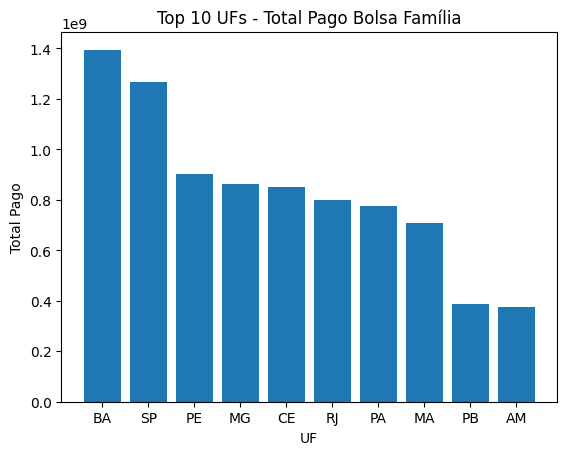

In [21]:
import matplotlib.pyplot as plt

df_uf = df_tratado.groupBy("uf") \
    .agg(sum("valor_parcela").alias("total_pago")) \
    .orderBy("total_pago", ascending=False) \
    .limit(10) \
    .toPandas()

# Gráfico
plt.figure()
plt.bar(df_uf["uf"], df_uf["total_pago"])
plt.title("Top 10 UFs - Total Pago Bolsa Família")
plt.xlabel("UF")
plt.ylabel("Total Pago")
plt.show()